# Prescriptive Analysis

## 1. Should insulin bolus dosage be adjusted when glucose spikes occur after periods of inactivity?
Markers Chosen
* glucose
* steps
* bolus_volume_delivered
#### Why These Markers?
Low physical activity (steps) often contributes to higher glucose levels.
Bolus insulin is used to reduce post-meal glucose spikes.
Understanding the relationship helps recommend personalized insulin corrections.
Medical Influence
Sedentary behavior can reduce insulin sensitivity, causing glucose to remain elevated longer.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")

                         glucose     steps  bolus_volume_delivered
glucose                 1.000000  0.051286                0.020115
steps                   0.051286  1.000000                0.011746
bolus_volume_delivered  0.020115  0.011746                1.000000


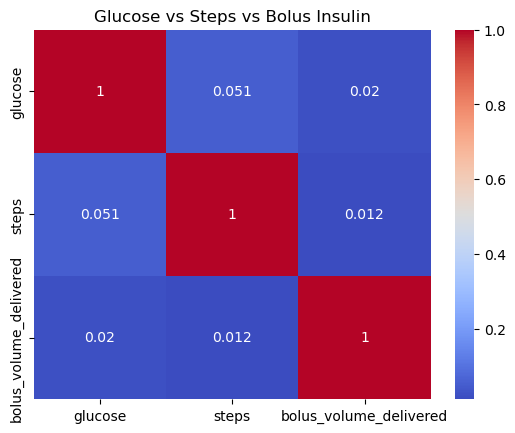

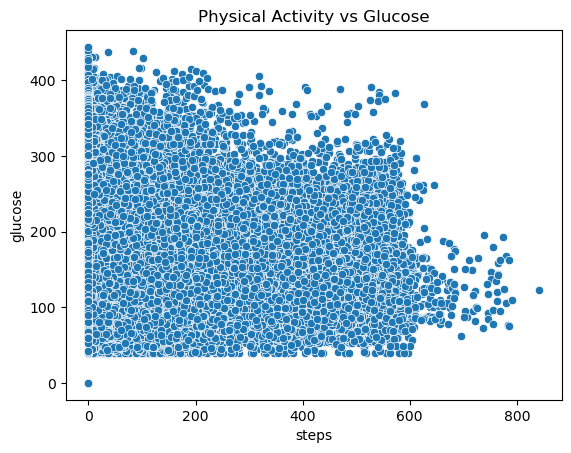

In [8]:
# Correlation analysis
corr = df[['glucose', 'steps', 'bolus_volume_delivered']].corr()
print(corr)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Glucose vs Steps vs Bolus Insulin")
plt.show()

# Scatterplot
sns.scatterplot(data=df, x='steps', y='glucose')
plt.title("Physical Activity vs Glucose")
plt.show()

#### Findings:
Despite a near-zero Pearson correlation (0.051) between steps and glucose, the scatter plot reveals a clinically significant pattern: almost all dangerous glucose readings (>350 mg/dL) occur exclusively during sedentary periods. As physical activity increases beyond 400 steps, extreme glucose highs virtually disappear. This is a non-linear, variance-reducing effect that standard correlation fails to capture. Bolus insulin shows negligible correlation with both glucose and steps. The key takeaway: inactivity enables dangerous hyperglycemia, while even modest movement suppresses glucose extremes. Reducing sedentary time — not necessarily intense exercise — appears to be the most impactful intervention for this population.

#### 2. Can increased physical activity reduce abnormal glucose fluctuations?
Markers Chosen
steps
glucose
calories
Why?
Steps indicate movement/activity.
Calories estimate energy expenditure.
Together they show whether exercise stabilizes glucose.

In [9]:
# Daily glucose variability
daily_var = df.groupby(df['time'].dt.date)['glucose'].std()

# Daily steps
daily_steps = df.groupby(df['time'].dt.date)['steps'].sum()

analysis = pd.DataFrame({
    'glucose_std': daily_var,
    'steps': daily_steps
})

print(analysis.corr())

sns.regplot(data=analysis, x='steps', y='glucose_std')
plt.title("Steps vs Glucose Variability")
plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [6]:
df.dtypes

time                             object
glucose                         float64
calories                        float64
heart_rate                      float64
steps                           float64
basal_rate                      float64
bolus_volume_delivered          float64
carb_input                      float64
Patient_ID                       object
Age                               int64
Gender                           object
Race                             object
Average Sleep Duration (hrs)    float64
Sleep Quality (1-10)            float64
% with Sleep Disturbances         int64
dtype: object